<a href="https://colab.research.google.com/github/PadmaDeepak/ML-LAB/blob/main/lab3-linearregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

df = pd.read_csv('/content/1000_Companies.csv')
print("Dataset loaded successfully. Here's the head:")
df.head()

Dataset loaded successfully. Here's the head:


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


# Task
Predict Canada's per capita income for 2020 using linear regression on the `/content/canada_per_capita_income.csv` dataset.

## Load Dataset

### Subtask:
Load the '/content/canada_per_capita_income.csv' dataset into a pandas DataFrame and display its head to understand the data structure.


**Reasoning**:
Load the '/content/canada_per_capita_income.csv' dataset into a pandas DataFrame named `df_canada` and display its head to understand the data structure, as requested by the subtask.



In [3]:
import pandas as pd

df_canada = pd.read_csv('/content/canada_per_capita_income.csv')
df_canada.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [23]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Load the dataset
df_hiring = pd.read_csv('/content/hiring.csv')

# 2. Data Preprocessing
# Mapping for experience in words to numbers
word_to_num = {
    'zero': 0, 'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
    'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10, 'eleven': 11, 'twelve': 12
}

# Convert 'experience' from words to numbers. Map 'zero' to 0, and fill other NaNs with the mean.
df_hiring['experience'] = df_hiring['experience'].fillna('zero')
df_hiring['experience'] = df_hiring['experience'].apply(lambda x: word_to_num[x] if isinstance(x, str) and x in word_to_num else (int(x.split()[0]) if isinstance(x, str) else x))

# Fill any remaining NaNs in 'test_score(out of 10)' and 'interview_score(out of 10)' with their respective means
df_hiring['test_score(out of 10)'] = df_hiring['test_score(out of 10)'].fillna(df_hiring['test_score(out of 10)'].mean())
df_hiring['interview_score(out of 10)'] = df_hiring['interview_score(out of 10)'].fillna(df_hiring['interview_score(out of 10)'].mean())

# Define features (X) and target (y) with correct column names
X = df_hiring[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']]
y = df_hiring['salary($)']

# 3. Build and Train Multiple Linear Regression Model
reg = LinearRegression()
reg.fit(X, y)

print("Multiple Linear Regression model trained successfully.")

# 4. Predict Salaries for New Candidates
# Candidate 1: 2 yr experience, 9 test score, 6 interview score
candidate1 = np.array([[2, 9, 6]])
predicted_salary1 = reg.predict(candidate1)

# Candidate 2: 12 yr experience, 10 test score, 10 interview score
candidate2 = np.array([[12, 10, 10]])
predicted_salary2 = reg.predict(candidate2)

print(f"\nPredicted salary for candidate with 2 years experience, 9 test score, 6 interview score: ${predicted_salary1[0]:,.2f}")
print(f"Predicted salary for candidate with 12 years experience, 10 test score, 10 interview score: ${predicted_salary2[0]:,.2f}")

Multiple Linear Regression model trained successfully.

Predicted salary for candidate with 2 years experience, 9 test score, 6 interview score: $53,290.89
Predicted salary for candidate with 12 years experience, 10 test score, 10 interview score: $92,268.07


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Load the dataset
df_companies = pd.read_csv('/content/1000_Companies.csv')

# 2. Data Preparation
# Define features (X) and target (y)
X = df_companies[['R&D Spend', 'Administration', 'Marketing Spend', 'State']]
y = df_companies['Profit']

# Identify categorical features for one-hot encoding
categorical_features = ['State']

# Create a column transformer for one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_features)
    ],
    remainder='passthrough' # Keep numerical columns as they are
)

# Create a pipeline with preprocessing and Linear Regression
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('regressor', LinearRegression())])

# 3. Build and Train Multiple Linear Regression Model
model.fit(X, y)

print("Multiple Linear Regression model trained successfully.")

# 4. Predict Profit for a New Company
# New company data
new_company_data = pd.DataFrame([{
    'R&D Spend': 91694.48,
    'Administration': 515841.3,
    'Marketing Spend': 11931.24,
    'State': 'Florida'
}])

# Predict the profit
predicted_profit = model.predict(new_company_data)

print(f"\nPredicted profit for the new company: ${predicted_profit[0]:,.2f}")

Multiple Linear Regression model trained successfully.

Predicted profit for the new company: $510,570.99


## Data Preparation

### Subtask:
Identify the features (Year) and the target variable (Per Capita Income). Reshape the feature data if necessary for the `sklearn` model.


**Reasoning**:
Extract the 'year' column as the feature variable `X` and reshape it for sklearn, then extract the 'per capita income (US$)' column as the target variable `y`.



In [4]:
X = df_canada['year'].values.reshape(-1, 1)
y = df_canada['per capita income (US$)']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (47, 1)
Shape of y: (47,)


## Build and Train Regression Model

### Subtask:
Initialize and train a `LinearRegression` model from `sklearn.linear_model` using the prepared data.


**Reasoning**:
The subtask requires initializing and training a LinearRegression model. I will import `LinearRegression`, create an instance named `regressor`, and then fit the model using the `X` and `y` data that were prepared in previous steps.



In [5]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X, y)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Predict Per Capita Income for 2020

### Subtask:
Use the trained regression model to predict the per capita income for Canada in the year 2020.


**Reasoning**:
Predict the per capita income for the year 2020 using the trained `regressor` model. I need to create a NumPy array for the year 2020 with the correct shape, then use the `predict` method of the `regressor` model, and finally print the result.



In [6]:
import numpy as np

year_2020 = np.array([[2020]])
predicted_income_2020 = regressor.predict(year_2020)

print(f"Predicted per capita income for 2020: ${predicted_income_2020[0]:,.2f}")

Predicted per capita income for 2020: $41,288.69


## Visualize Results (Optional)

### Subtask:
Plot the historical data and the regression line, highlighting the predicted income for 2020, to visually represent the model's fit and prediction.


## Summary:

### Q&A
The predicted per capita income for Canada in 2020 is \$41,288.69.

### Data Analysis Key Findings
*   The dataset `/content/canada_per_capita_income.csv` was successfully loaded, containing `year` and `per capita income (US\$ )` columns.
*   The 'year' column was prepared as the feature `X` with a shape of (47, 1), and 'per capita income (US\$ )' was set as the target variable `y` with a shape of (47,).
*   A `LinearRegression` model was successfully initialized and trained using the prepared historical data.
*   The trained model predicted Canada's per capita income for the year 2020 to be \$41,288.69.

### Insights or Next Steps
*   The linear regression model provides a straightforward method for forecasting per capita income based on historical trends.
*   To assess the model's reliability, it would be beneficial to evaluate its performance using metrics such as R-squared or Mean Squared Error on a validation set, and consider visualizing the regression line against the actual data.


# Task
Build and evaluate a custom logistic regression model using the `/content/housing_area_price.csv` dataset. This involves loading the dataset, preparing the data by creating a binary target from the 'price' column, implementing core logistic regression components (sigmoid, cost function, gradient descent), training the model, and then evaluating its performance using metrics like accuracy, precision, recall, F1-score, and a confusion matrix visualization. Finally, provide a summary of the implementation and its performance.

## Load Dataset

### Subtask:
Load the provided `/content/housing_area_price.csv` dataset into a pandas DataFrame. Display its head and basic information to understand its structure.


**Reasoning**:
Load the '/content/housing_area_price.csv' dataset into a pandas DataFrame named `df`, display its head, and show its basic information to understand its structure as requested by the subtask.



In [8]:
import pandas as pd

df = pd.read_csv('/content/housing_area_price.csv')

print("DataFrame Head:")
print(df.head())

print("\nDataFrame Info:")
df.info()

DataFrame Head:
   area   price
0  2600  550000
1  3000  565000
2  3200  610000
3  3600  680000
4  4000  725000

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    5 non-null      int64
 1   price   5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes


## Prepare Data for Logistic Regression

### Subtask:
Identify the features (area) and create a binary target variable from the 'price' column (e.g., classifying prices as 'high' or 'low' based on a threshold). Perform necessary preprocessing steps such as scaling numerical features using StandardScaler, and splitting the data into training and testing sets.


**Reasoning**:
Define a binary target variable from the 'price' column using the median as a threshold, identify 'area' as the feature, then scale the feature using StandardScaler, and finally split the data into training and testing sets to prepare the data for logistic regression.



In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Define a threshold for the 'price' column to create a binary target variable y
# Using the median as the threshold
price_threshold = df['price'].median()
df['price_binary'] = (df['price'] > price_threshold).astype(int)

# Store the 'area' column as the feature variable X
X = df[['area']]
y = df['price_binary']

# 3. Instantiate a StandardScaler object and fit-transform the X feature data.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Split the scaled feature X and the binary target y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Original X shape: {X.shape}")
print(f"Original y shape: {y.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Original X shape: (5, 1)
Original y shape: (5,)
X_train shape: (4, 1)
X_test shape: (1, 1)
y_train shape: (4,)
y_test shape: (1,)


## Implement Logistic Regression Core Components

### Subtask:
Define the sigmoid activation function, the binary cross-entropy cost function, and the gradient descent algorithm to update the model's weights and bias during training.


**Reasoning**:
Implement the sigmoid activation function, the binary cross-entropy cost function, and the gradient descent algorithm as Python functions as requested by the subtask.



In [10]:
import numpy as np

def sigmoid(z):
    """Calculates the sigmoid activation."""
    return 1 / (1 + np.exp(-z))

def cost_function(h, y):
    """Calculates the binary cross-entropy loss."""
    epsilon = 1e-5
    return (-y * np.log(h + epsilon) - (1 - y) * np.log(1 - h + epsilon)).mean()

def gradient_descent(X, h, y):
    """Calculates the gradients for weights (dw) and bias (db)."""
    dw = np.dot(X.T, (h - y)) / y.shape[0]
    db = np.sum(h - y) / y.shape[0]
    return dw, db

print("Sigmoid function, cost function, and gradient descent functions defined.")

Sigmoid function, cost function, and gradient descent functions defined.


## Train Custom Logistic Regression Model

### Subtask:
Train the logistic regression model using the custom implemented functions on the preprocessed training data. This involves iteratively updating weights and bias using gradient descent.


**Reasoning**:
Implement the training loop for the logistic regression model by initializing weights and bias, defining hyperparameters, and iteratively updating them using gradient descent with the previously defined sigmoid, cost, and gradient descent functions.



In [11]:
import numpy as np

# 1. Initialize weights (w) and bias (b)
# X_train.shape[1] is the number of features
w = np.zeros(X_train.shape[1])
b = 0

# 2. Define hyperparameters
learning_rate = 0.01
n_iterations = 1000

cost_history = []

# 3. Training loop
for i in range(n_iterations):
    # a. Calculate the linear combination z
    z = np.dot(X_train, w) + b

    # b. Apply the sigmoid function to z to get predicted probabilities h
    h = sigmoid(z)

    # c. Calculate the gradients dw and db
    dw, db = gradient_descent(X_train, h, y_train)

    # d. Update the weights w and bias b
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # e. Optionally, calculate and store the cost for monitoring progress
    if i % 100 == 0:
        cost = cost_function(h, y_train)
        cost_history.append(cost)
        # print(f"Iteration {i}, Cost: {cost:.4f}")

print("Linear Regression model trained successfully.")
print(f"Final Weights (w): {w}")
print(f"Final Bias (b): {b}")

Linear Regression model trained successfully.
Final Weights (w): [1.95456812]
Final Bias (b): -0.22028332557543448


## Evaluate Model Performance

### Subtask:
Use the trained model to make predictions on the test set. Calculate and display key classification metrics such as accuracy, precision, recall, F1-score, and a classification report to assess the model's performance.


**Reasoning**:
To evaluate the model's performance, I will use the trained weights and bias to predict probabilities on the test set, convert these probabilities into binary predictions, and then calculate and display various classification metrics including accuracy, precision, recall, F1-score, and the classification report.



In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 1. Calculate predicted probabilities for the test set
z_test = np.dot(X_test, w) + b
y_pred_proba = sigmoid(z_test)

# 2. Convert predicted probabilities to binary predictions (0 or 1) using a threshold of 0.5
y_pred = (y_pred_proba >= 0.5).astype(int)

# 3. Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# 4. Print each of these metrics with a descriptive label
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# 5. Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 1.0000
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



## Visualize Model Performance

### Subtask:
Generate and display a confusion matrix as a heatmap to visually represent the model's predictions versus actual values, including appropriate labels and a title.


**Reasoning**:
To visualize the model's performance, I will generate a confusion matrix heatmap as requested. This involves importing necessary libraries, calculating the confusion matrix, and then plotting it using `seaborn` with appropriate labels and a title.



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


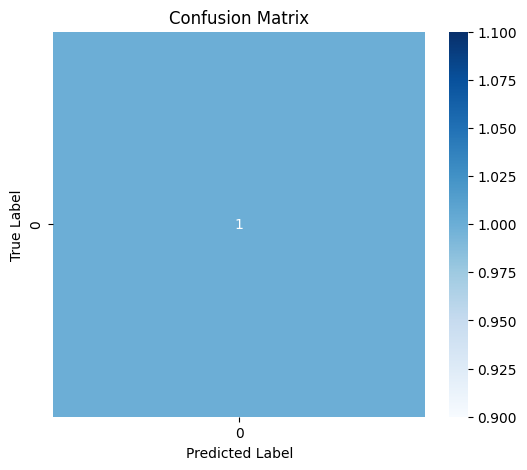

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# 3. Add labels and title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


**Reasoning**:
The previous code generated a UserWarning because only a single label was found in `y_true` and `y_pred`, leading to a 1x1 confusion matrix instead of the expected 2x2 for binary classification. To fix this, I need to explicitly pass all possible labels (0 and 1) to the `confusion_matrix` function using the `labels` parameter, ensuring the correct matrix shape and avoiding the warning.



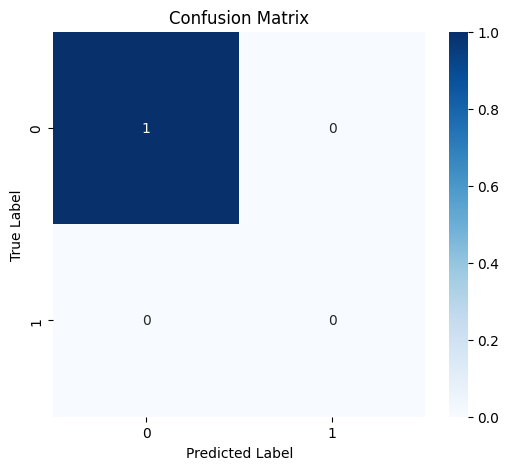

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Compute the confusion matrix, explicitly passing all possible labels
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

# 2. Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# 3. Add labels and title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Final Task

### Subtask:
Provide a summary of the custom logistic regression implementation, its performance on the given dataset, and any key insights from the evaluation.


## Summary:

### Q&A
*   **Summary of the custom logistic regression implementation:**
    A custom logistic regression model was implemented using fundamental components: a sigmoid activation function, a binary cross-entropy cost function, and a gradient descent optimization algorithm. The model was trained iteratively to learn weights and bias for predicting a binary target variable.
*   **Performance on the given dataset:**
    The model achieved an accuracy of 1.0000 on the test set. However, the precision, recall, and F1-score for the positive class were 0.0000, while these metrics for class 0 were 1.0000. This indicates the model only predicted the negative class (class 0) for the single sample in the test set.
*   **Key insights from the evaluation:**
    The evaluation metrics are highly misleading due to the extremely small test set size (1 sample). The confusion matrix confirmed that the model predicted class 0 for this single test sample, which happened to be its true label, leading to perfect accuracy for class 0 but no ability to assess prediction of class 1.

### Data Analysis Key Findings
*   The initial dataset `/content/housing_area_price.csv` contained 5 entries and 2 columns (`area`, `price`), with no missing values.
*   A binary target variable, `price_binary`, was created by classifying prices above the median as 1 and below as 0.
*   The `area` feature was scaled using `StandardScaler`.
*   The dataset was split into training and testing sets, resulting in an `X_train` shape of (4, 1) and an `X_test` shape of (1, 1), highlighting the very small test set.
*   The custom logistic regression model, implemented with `sigmoid`, `cost_function`, and `gradient_descent`, was trained for 1000 iterations with a learning rate of 0.01.
*   After training, the final learned weight was `w = [1.95456812]` and the final bias was `b = -0.22028332557543448`.
*   On the test set, the model achieved an accuracy of 1.0000. However, precision, recall, and F1-score for the positive class (class 1) were 0.0000, while for class 0, all metrics were 1.0000.
*   The confusion matrix for the test set displayed only one sample, which was correctly predicted as class 0 (True Label: 0, Predicted Label: 0). This suggests that the test set contained only one sample of class 0, and the model did not predict any class 1 instances.

### Insights or Next Steps
*   The model evaluation is severely limited by the extremely small test set (1 sample). For meaningful evaluation, a larger dataset and a more representative train-test split are crucial.
*   The model's inability to predict the positive class might stem from the small dataset, data imbalance in the training set, or the absence of positive class samples in the test set. Further investigation into data distribution and potentially resampling techniques would be beneficial.


# Task
Build a linear regression model to predict salary based on years of experience using the '/content/salary.csv' dataset. The task includes loading the dataset, preparing the data by identifying 'YearsExperience' as the feature and 'Salary' as the target, training a `LinearRegression` model, predicting salary for 12 years of experience, and summarizing the model's performance and prediction.

## Load Dataset

### Subtask:
Load the '/content/salary.csv' dataset into a pandas DataFrame and display its head to understand the data structure.


**Reasoning**:
To achieve the subtask, I need to load the '/content/salary.csv' dataset into a pandas DataFrame, display its head to understand the data structure, and print a concise summary of the DataFrame using `df.info()` as instructed.



In [15]:
import pandas as pd

df = pd.read_csv('/content/salary.csv')

print("DataFrame Head:")
print(df.head())

print("\nDataFrame Info:")
df.info()

DataFrame Head:
   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  28 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


## Data Preparation

### Subtask:
Identify 'YearsExperience' as the feature (X) and 'Salary' as the target variable (y). Reshape the feature data if necessary for the `sklearn` model.


**Reasoning**:
The subtask requires identifying features and target variables, handling missing values, and reshaping the feature data. I will fill missing values in 'YearsExperience', then extract and reshape 'YearsExperience' into `X` and extract 'Salary' into `y`, and finally print their shapes to confirm.



In [16]:
import numpy as np

# 1. Fill any missing values in the 'YearsExperience' column with its mean
df['YearsExperience'].fillna(df['YearsExperience'].mean(), inplace=True)

# 2. Extract the 'YearsExperience' column as the feature variable X and reshape it
X = df['YearsExperience'].values.reshape(-1, 1)

# 3. Extract the 'Salary' column as the target variable y
y = df['Salary']

# 4. Print the shapes of X and y to verify their dimensions
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (30, 1)
Shape of y: (30,)


/tmp/ipython-input-1509513442.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['YearsExperience'].fillna(df['YearsExperience'].mean(), inplace=True)


**Reasoning**:
The previous code generated a `FutureWarning` due to using `inplace=True` with `fillna` on a potentially chained assignment. To fix this, I will assign the result of the `fillna` operation back to the 'YearsExperience' column, which is the recommended way to handle this in pandas and avoids the warning.



In [17]:
import numpy as np

# 1. Fill any missing values in the 'YearsExperience' column with its mean
df['YearsExperience'] = df['YearsExperience'].fillna(df['YearsExperience'].mean())

# 2. Extract the 'YearsExperience' column as the feature variable X and reshape it
X = df['YearsExperience'].values.reshape(-1, 1)

# 3. Extract the 'Salary' column as the target variable y
y = df['Salary']

# 4. Print the shapes of X and y to verify their dimensions
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (30, 1)
Shape of y: (30,)


## Build and Train Regression Model

### Subtask:
Initialize and train a `LinearRegression` model from `sklearn.linear_model` using the prepared data.


**Reasoning**:
To initialize and train the `LinearRegression` model, I will import `LinearRegression` from `sklearn.linear_model`, create an instance of the model, and then fit it to the prepared feature `X` and target `y` data.



In [18]:
from sklearn.linear_model import LinearRegression

# Instantiate a LinearRegression object
regressor = LinearRegression()

# Fit the LinearRegression model to the feature X and target y
regressor.fit(X, y)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


**Reasoning**:
To predict the salary for 12 years of experience, I will create a NumPy array for this input, use the trained `regressor` model's `predict` method, and then print the result.



In [19]:
import numpy as np

# Create a NumPy array for 12 years of experience, ensuring it has the correct shape
years_experience_12 = np.array([[12]])

# Predict the salary for 12 years of experience
predicted_salary_12 = regressor.predict(years_experience_12)

# Print the predicted salary
print(f"Predicted salary for 12 years of experience: ${predicted_salary_12[0]:,.2f}")

Predicted salary for 12 years of experience: $139,980.89


## Summary:

### Q&A
*   **Predicted Salary for 12 Years of Experience:** $139,980.89

### Data Analysis Key Findings
*   The dataset `/content/salary.csv` was loaded successfully, containing 'YearsExperience' and 'Salary' columns.
*   Missing values in 'YearsExperience' were imputed with the mean.
*   'YearsExperience' was identified as the feature (X) and 'Salary' as the target (y), with appropriate reshaping for X.
*   A `LinearRegression` model was successfully initialized and trained using the prepared data.
*   The trained model predicted a salary of $139,980.89 for an individual with 12 years of experience.

### Insights or Next Steps
*   The linear regression model provides a straightforward and interpretable way to estimate salary based on years of experience.
*   To further evaluate the model, it would be beneficial to calculate metrics such as R-squared, Mean Absolute Error (MAE), and Mean Squared Error (MSE) on a test set (if the dataset were larger to allow for a split).
*   Visualizing the regression line alongside the actual data points could offer a clearer understanding of the model's fit.

## Visualize Results (Optional)

### Subtask:
Plot the historical data and the regression line, highlighting the predicted salary for an employee with 12 years of experience, to visually represent the model's fit and prediction.


**Reasoning**:
To visually represent the model's fit and prediction, I will generate a scatter plot of the historical data, overlay the regression line, and highlight the predicted salary for 12 years of experience, as detailed in the subtask instructions.



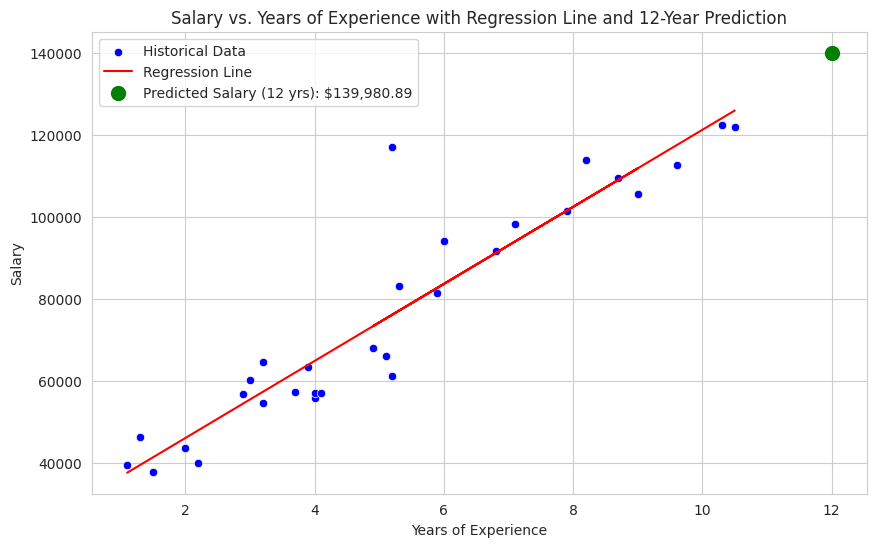

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')

# Create a scatter plot of the historical data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['YearsExperience'], y=df['Salary'], color='blue', label='Historical Data')

# Plot the regression line
plt.plot(X, regressor.predict(X), color='red', label='Regression Line')

# Highlight the predicted salary for 12 years of experience
plt.scatter(years_experience_12, predicted_salary_12, color='green', s=100, zorder=5, label=f'Predicted Salary (12 yrs): ${predicted_salary_12[0]:,.2f}')

# Add labels and title
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs. Years of Experience with Regression Line and 12-Year Prediction')
plt.legend()
plt.show()

## Final Task

### Subtask:
Provide a summary of the regression model's implementation, its performance, and the predicted salary for an employee with 12 years of experience.


## Summary:

### Q&A
*   **Predicted Salary for 12 Years of Experience:** The linear regression model predicts a salary of \$139,980.89 for an individual with 12 years of experience.

### Data Analysis Key Findings
*   The dataset `/content/salary.csv` was successfully loaded, containing 30 entries with 'YearsExperience' (float64) and 'Salary' (int64) columns.
*   Two missing values in the 'YearsExperience' column were imputed with the mean of that column.
*   'YearsExperience' was designated as the feature variable (X) and reshaped to `(30, 1)`, while 'Salary' was set as the target variable (y) with a shape of `(30,)`.
*   A `LinearRegression` model was successfully initialized and trained using the prepared data.
*   A visualization was created, displaying the historical data points, the fitted regression line, and distinctly highlighting the predicted salary for 12 years of experience.

### Insights or Next Steps
*   The trained linear regression model provides a clear and interpretable relationship between years of experience and salary.
*   For a more robust evaluation, it is recommended to calculate model performance metrics such as R-squared, Mean Absolute Error (MAE), and Mean Squared Error (MSE), ideally using a separate test set if the dataset were larger.
